<a href="https://colab.research.google.com/github/wavymejti/KursAI1/blob/main/pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
print(pd.__version__)

2.2.2


In [5]:
#przykład tworzenia Series na podstawie słownika i listy

data = {"anna": 25, "Jan" : 30, "Kasie" : 55, "Błażej" : 16}

s = pd.Series(data)

print(s)

s = pd.Series([18, 16, 17, 20, np.nan], index=['Kuba', 'Ania', 'Władysław', 'Bartek', 'nieznajomy'])

print(s)

print(f'Rozmiar serii {s.size}')
print(f'Kształt serii {s.shape}')
print(f'Typ danych serii {s.dtype}')
print(f'Indeksy w serii {s.index}')
print(f'Wartości w serii {s.values}')
print(f'Wartość dla klucza Bartek` {s["Bartek"]}')
print(f'Wartość elementu na pozycji {s.iloc[1]}')

anna      25
Jan       30
Kasie     55
Błażej    16
dtype: int64
Kuba          18.0
Ania          16.0
Władysław     17.0
Bartek        20.0
nieznajomy     NaN
dtype: float64
Rozmiar serii 5
Kształt serii (5,)
Typ danych serii float64
Indeksy w serii Index(['Kuba', 'Ania', 'Władysław', 'Bartek', 'nieznajomy'], dtype='object')
Wartości w serii [18. 16. 17. 20. nan]
Wartość dla klucza Bartek` 20.0
Wartość elementu na pozycji 16.0


In [7]:
data = {
    "cena": [15,20,17],
    "ilość": [50,40,45]
}

df = pd.DataFrame(data, index=['mleko', 'ser', 'chleb'])

print(df)
df

       cena  ilość
mleko    15     50
ser      20     40
chleb    17     45


,cena,ilość
mleko,15,50
ser,20,40
chleb,17,45


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, mleko to chleb
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   cena    3 non-null      int64
 1   ilość   3 non-null      int64
dtypes: int64(2)
memory usage: 180.0+ bytes
None


In [9]:
#1 wczytanie pliku i wyswietlenie 10 pierwszych rekordów
df = pd.read_csv('Pokemon.csv')
df.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


In [10]:
#wyswietlenie liczby unikalnych typow 1 pokemonow
df['Type 1'].nunique()

18

In [13]:
# policz ile pokomenow jest legendarnych
print(f'liczba legendarnych poksów {df['Legendary'].sum()}')

print(f'liczba legendarnych poksów {df['Legendary'].value_counts()[True]}')

print(f'liczba legendarnych poksów {len(df[df['Legendary'] == True])}')

liczba legendarnych poksów 65
liczba legendarnych poksów 65
liczba legendarnych poksów 65


In [14]:
#sprawdz ile pokemonow nie ma drugiego typu
print(f'liczba pokemonow bez drugiego typu {len(df[df["Type 2"].isnull()])}')

liczba pokemonow bez drugiego typu 386


In [15]:
#znajdz poksy z najwyzsza wartoscia Total
df[df['Total'] == df['Total'].max()]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
164,150,MewtwoMega Mewtwo Y,Psychic,NaN,780,106,150,70,194,120,140,1,True
426,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True


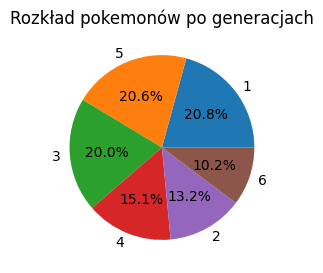

In [17]:
#zlicz pokemony z kazdej generacji i narysuj wykres kolowy prezentujacy ich liczbe
import matplotlib.pyplot as plt
generation_Counts = df['Generation'].value_counts()
plt.figure(figsize=(3,3))
plt.pie(generation_Counts, labels=generation_Counts.index, autopct='%1.1f%%')
plt.title('Rozkład pokemonów po generacjach')
plt.show()

In [18]:
#znajdz wszystkie pokemony ktorych glowny typ to ogien
df[df["Type 1"] == "Fire"]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
42,37,Vulpix,Fire,NaN,299,38,41,40,50,65,65,1,False
43,38,Ninetales,Fire,NaN,505,73,76,75,81,100,100,1,False
63,58,Growlithe,Fire,NaN,350,55,70,45,70,50,60,1,False
64,59,Arcanine,Fire,NaN,555,90,110,80,100,80,95,1,False
83,77,Ponyta,Fire,NaN,410,50,85,55,65,65,90,1,False


In [20]:
#wyswietl wszystkie poksy ktora maja hp wieksze niz 100
df[df["HP"] > 100]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
44,39,Jigglypuff,Normal,Fairy,270,115,45,20,45,25,20,1,False
45,40,Wigglytuff,Normal,Fairy,435,140,70,45,85,50,45,1,False
96,89,Muk,Poison,NaN,500,105,105,75,65,100,50,1,False
120,112,Rhydon,Ground,Rock,485,105,130,120,45,45,40,1,False
121,113,Chansey,Normal,NaN,450,250,5,5,35,105,50,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
753,683,Aromatisse,Fairy,NaN,462,101,72,72,99,89,29,6,False
769,699,Aurorus,Rock,Ice,521,123,77,72,99,92,58,6,False
792,716,Xerneas,Fairy,NaN,680,126,131,95,131,98,99,6,True
793,717,Yveltal,Dark,Flying,680,126,131,95,131,98,99,6,True


In [21]:
#wyswietl legendarne poksy z speed > 120
df[(df["Legendary"]) & (df["Speed"] > 120)]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
162,150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
164,150,MewtwoMega Mewtwo Y,Psychic,NaN,780,106,150,70,194,120,140,1,True
428,386,DeoxysNormal Forme,Psychic,NaN,600,50,150,50,150,50,150,3,True
429,386,DeoxysAttack Forme,Psychic,NaN,600,50,180,20,180,20,150,3,True
431,386,DeoxysSpeed Forme,Psychic,NaN,600,50,95,90,95,90,180,3,True
549,491,Darkrai,Dark,NaN,600,70,90,90,135,90,125,4,True
551,492,ShayminSky Forme,Grass,Flying,600,100,103,75,120,75,127,4,True
703,641,TornadusTherian Forme,Flying,NaN,580,79,100,80,110,90,121,5,True
